# Importing

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
#--------------- IMPORTING FROM FILES ---------------#
currentdir = os.getcwd()
parentdir = os.path.dirname(currentdir)
#--------------- FILES PARENTDIR ---------------#
sys.path.insert(0, parentdir)
from NFW_class import NFW_profile, r1
from Isothermal_paper_2206 import findTwoDeltaMinimum, findTwoDeltaMinimum_vol2
from CoreNFW_class import find_fitting_parm, coreNFW
from velDisp_class import VelDisp_fit
import Config as cfg  # helpfull functions and constans
import AuxiliaryFunctions as aux

# SETS OF SIMULATION: USER SETS!

In [2]:
# annihilation cross-section
sigma_m = 1.0  # [cm^2/g]
sigma_m_SI = sigma_m * 10 ** (-4) * 10 ** 3  # [m^2/kg]
# Viral mass
M_vir = 10 ** 11.04  # [M_sun]
# concentration of DM
const_c = 15.2  # dimensionless

# Evolution time of galaxy
tage_grid = np.logspace(-5 * 0.1, 2.5, 50)  # [Gyr] # for c = 15.2, sigma_m = 1.0, M_vir = 10**11.04
diff_tim = len(tage_grid)

# CREATING NFW CLASS: starts of evolution


In [3]:
NFW_profile = NFW_profile(M_vir, const_c)
r_s = NFW_profile.r_s
rounded_r_s = cfg.rounded_number(r_s, 3)

rho_s = NFW_profile.rho_s
rounded_rho_s = cfg.rounded_number(rho_s, 3)
print(f"rho_s = {rounded_rho_s} [M_solar / kpc^3], r_s = {rounded_r_s} [kpc]")

rho_s = 17700000.0 [M_solar / kpc^3], r_s = 6.43 [kpc]


# LOOP FOR EVERY TIME: USER SETS!

In [4]:
nums_r = 600  # for how many radius we want data in .txt  file
r = np.logspace(-0.5, 2.5, nums_r)  # radius: 500 for -2., 2.

r1marge = 0  # [kpc], value of r1 when merging occurs
tmarge = 0  # merging time in [Gyr]
merged_appear = False  # flag to find the first time when physical and unphysical have comparable values

rel_err_margin = 1.0 # when mergin appers

In [5]:
for time in range(0, diff_tim):
    ####################### BASIC VARAIBLES #######################
    # selected time
    tage = tage_grid[time]  # [Gyr]
    # simulation parameters
    sim_parms = [M_vir, const_c, sigma_m, tage]

    # -------------- FINDING R1 OF OUR PROFILE --------------#
    # new one way to get r1
    r_1 = r1(NFW_profile, sigmamx=sigma_m, tage=tage)
    # rounded_r1 = cfg.rounded_number(r_1, 5)
    # print("potential r_1:", potential_r_1)
    # print(f"r_1 = {rounded_r1} [kpc]")

    ####################### ISOTHERMAL #######################
    # Isothermal: low dense, high dense
    SIDM_LoDens, SIDM_HiDens = findTwoDeltaMinimum(r_1, NFW_profile)  # by default r_low=-3.
    # SIDM_LoDens, SIDM_HiDens = findTwoDeltaMinimum(r_1, NFW_profile, r_low=-2.)

    ####################### SAVE NECESSARY DATA #######################
    # find the density values
    rhodm0_LoDens = SIDM_LoDens[0]  # [M_sun/kpc^3]
    rhodm0_HiDens = SIDM_HiDens[0]  # [M_sun/kpc^3]

    # ---------------------- SEARCHING TMARGE: USER SETS! ----------------------#
    Is_merging = aux.calRelErr_mergin(rhodm0_HiDens, rhodm0_LoDens, rel_err_margin)

    if (Is_merging == True) and merged_appear == False:
        # we find margin two densities
        merged_appear = True
        tmarge = tage  # [Gyr]
        r1marge = r_1  # [kpc]
        rhomarge = rhodm0_LoDens
        # print('r1 value during merging:', r_1, '[kpc]')

C:\Users\Krzysztof\Documents\GitHub\DarkMatterProfiles\R-procedure\NFW-Isothermal-paper-2206\Isothermal_paper_2206.py:320: OptimizeWarning: Initial guess is not within the specified bounds
  res = minimize(deltaSqare,[lgrhodm0_init,lgsigma0_init],


# AFTER LOOP: COLLECT DATA

In [6]:
"""
firstly we have to
"""
r_ISO = np.array([])  # isothermal radius, r in [r_min, r1]
r_NFW = np.array([])  # NFW radius, r in [r1, r_max]

In [7]:
print('r1marge', r1marge)
print('rhomarge:', rhomarge)
print('t1marge:,', tmarge)

for i in range(0, len(r)):
    if (r[i] < r1marge):
        r_ISO = np.append(r_ISO, r[i])
    else:
        r_NFW = np.append(r_NFW, r[i])

Nr_ISO = len(r_ISO)  # number of radius's for isothermal
Nr_NFW = len(r_NFW)  # number of radius's for NFW

# print('Nr_ISO:', Nr_ISO, 'r_ISO:', r_ISO)
# print('Nr_NFW:', Nr_NFW, 'r_NFW:', r_NFW)

r1marge 29.02331157869934
rhomarge: 38151256.3658011
t1marge:, 316.22776601683796


In [8]:
#---------------------- COLLECT DATA FROM: ISOTHERMALL ----------------------#
SIDM_LoDens, SIDM_HiDens = findTwoDeltaMinimum_vol2(r1marge, NFW_profile, r_ISO)  # by default r_low=-3.

In [9]:
'''
Collect the data which we want to save in .txt file.
Time of merging in right units:

    time_m = np.log10(tage) # [log10(Gyr)]

List of radius's:

    radius_m = SIDM_LoDens[4] # [kpc]

List of densities:

    density_m = SIDM_LoDens[2] # [M_sun / kpc^3]
'''
time_m = np.log10(tmarge)  # [log10(Gyr)]
r_m_ISO = np.array(SIDM_LoDens[4])  # [kpc]: at merging
density_m_ISO = np.array(SIDM_LoDens[2])  # [M_sun / kpc^3]: at merging /rho(r, tmerge)
# get them all
data_m_ISO = [time_m, Nr_ISO, density_m_ISO]

# for i in  range(0, Nr_ISO):
#     print('r_ISO[i]:', r_ISO[i], 'radius_m_ISO', radius_m_ISO[i])
#    # have the same value up to 3-th significant number

# Use our data to fit to the `core NFW` model

In [10]:
# do a fitting
rc, r_ISO_inrp, rho_ISO_inrp = find_fitting_parm(NFW_profile, r_m_ISO, density_m_ISO)
print(f'fitting parameter r_c is given by: {rc} [kpc]')

fitting parameter r_c is given by: [3.74831738] [kpc]


In [11]:
# create a class core NFW
# denotion: cNFW
coreNFW_class = coreNFW(M_vir, const_c, rc)

In [12]:
# collect the data from core NFW, radius and density
r_m_cNFW = np.array(r)
density_m_cNFW = coreNFW_class.rho(r_m_cNFW)

# Plot

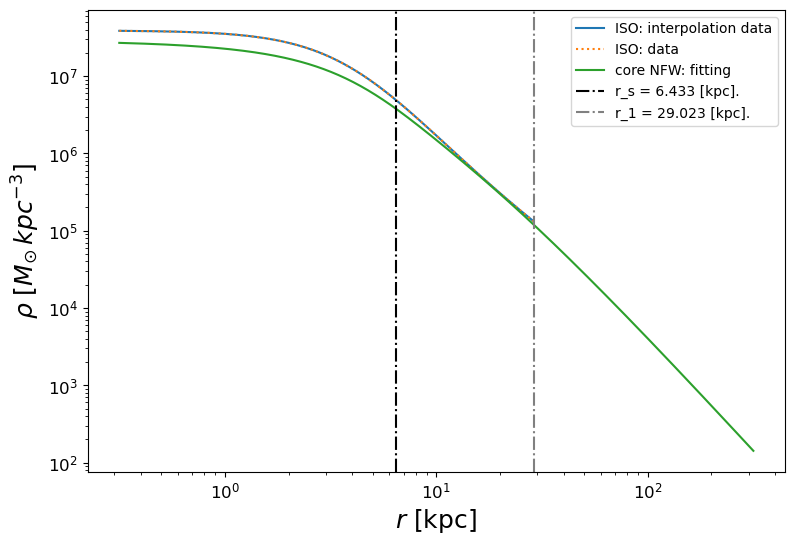

In [13]:
# Plotting
fig, ax = plt.subplots(figsize=(9.0, 6.0))
ax.plot(r_ISO_inrp, rho_ISO_inrp, label="ISO: interpolation data")
ax.plot(r_m_ISO, density_m_ISO, label="ISO: data", linestyle='dotted')
ax.plot(r_m_cNFW, density_m_cNFW, label="core NFW: fitting")
# lines
plt.axvline(x=r_s, color='black', linestyle='dashdot',
                    label=f'r_s = {"{:.3f}".format(r_s)} [kpc].')
plt.axvline(x=r1marge, color='grey', linestyle='dashdot',
                    label=f'r_1 = {"{:.3f}".format(r1marge)} [kpc].')
# log scale
ax.set_xscale('log')
ax.set_yscale('log')
# describe NFW profile
plt.ylabel(r"$\rho \, \, [M_{\odot} \, kpc^{-3}]$", fontsize=18)
plt.xlabel(r"$r$ [kpc]", fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.legend()
plt.show()

# Velocity dispersion in `core NFW` model

In [14]:
# calclculating velocity disparsion from `core NFW` model
velDisp_cNFW = coreNFW_class.sigma_accurate(r)

In [15]:
# calculating velocity disparsion from `NFW` model
velDisp_NFW = NFW_profile.sigma_accurate(r)

In [16]:
# define `core Isothermal` model
coreISO_class = VelDisp_fit(NFW_profile, r_m_ISO, density_m_ISO, r)

c_r: [1.94089827]


In [17]:
# calculating velocity dispersion from `core Isothermal` model
velDisp_cISO = coreISO_class.velDis()

velDis_sqare: [2453.22885289]
step: 0

velDis_sqare: [2456.37692753]
step: 1

velDis_sqare: [2459.52992804]
step: 2

velDis_sqare: [2462.68811076]
step: 3

velDis_sqare: [2465.8517296]
step: 4

velDis_sqare: [2469.02103608]
step: 5

velDis_sqare: [2472.19627923]
step: 6

velDis_sqare: [2475.37770567]
step: 7

velDis_sqare: [2478.56555956]
step: 8

velDis_sqare: [2481.76008259]
step: 9

velDis_sqare: [2484.961514]
step: 10

velDis_sqare: [2488.17009052]
step: 11

velDis_sqare: [2491.38604641]
step: 12

velDis_sqare: [2494.60961345]
step: 13

velDis_sqare: [2497.84102089]
step: 14

velDis_sqare: [2501.08049547]
step: 15

velDis_sqare: [2504.3282614]
step: 16

velDis_sqare: [2507.58454037]
step: 17

velDis_sqare: [2510.8495515]
step: 18

velDis_sqare: [2514.12351139]
step: 19

velDis_sqare: [2517.40663404]
step: 20

velDis_sqare: [2520.69913089]
step: 21

velDis_sqare: [2524.00121079]
step: 22

velDis_sqare: [2527.31308]
step: 23

velDis_sqare: [2530.63494218]
step: 24

velDis_sqare: [253

velDis_sqare: [3391.1009039]
step: 206

velDis_sqare: [3396.58762316]
step: 207

velDis_sqare: [3402.0387083]
step: 208

velDis_sqare: [3407.45212899]
step: 209

velDis_sqare: [3412.82582238]
step: 210

velDis_sqare: [3418.15769443]
step: 211

velDis_sqare: [3423.4456214]
step: 212

velDis_sqare: [3428.68745141]
step: 213

velDis_sqare: [3433.88100606]
step: 214

velDis_sqare: [3439.02408214]
step: 215

velDis_sqare: [3444.11445347]
step: 216

velDis_sqare: [3449.14987272]
step: 217

velDis_sqare: [3454.1280734]
step: 218

velDis_sqare: [3459.04677189]
step: 219

velDis_sqare: [3463.90366949]
step: 220

velDis_sqare: [3468.69645463]
step: 221

velDis_sqare: [3473.42280506]
step: 222

velDis_sqare: [3478.08039013]
step: 223

velDis_sqare: [3482.66687312]
step: 224

velDis_sqare: [3487.17991361]
step: 225

velDis_sqare: [3491.61716994]
step: 226

velDis_sqare: [3495.97630163]
step: 227

velDis_sqare: [3500.25497186]
step: 228

velDis_sqare: [3504.45085004]
step: 229

velDis_sqare: [3508.

velDis_sqare: [2446.60515089]
step: 407

velDis_sqare: [2434.60614455]
step: 408

velDis_sqare: [2422.60507984]
step: 409

velDis_sqare: [2410.60284063]
step: 410

velDis_sqare: [2398.60030157]
step: 411

velDis_sqare: [2386.59832812]
step: 412

velDis_sqare: [2374.59777653]
step: 413

velDis_sqare: [2362.59949378]
step: 414

velDis_sqare: [2350.60431762]
step: 415

velDis_sqare: [2338.61307647]
step: 416

velDis_sqare: [2326.62658951]
step: 417

velDis_sqare: [2314.64566656]
step: 418

velDis_sqare: [2302.67110816]
step: 419

velDis_sqare: [2290.70370549]
step: 420

velDis_sqare: [2278.74424046]
step: 421

velDis_sqare: [2266.79348548]
step: 422

velDis_sqare: [2254.85220383]
step: 423

velDis_sqare: [2242.9211493]
step: 424

velDis_sqare: [2231.00106639]
step: 425

velDis_sqare: [2219.09269026]
step: 426

velDis_sqare: [2207.1967467]
step: 427

velDis_sqare: [2195.31395221]
step: 428

velDis_sqare: [2183.44501395]
step: 429

velDis_sqare: [2171.59062976]
step: 430

velDis_sqare: [215

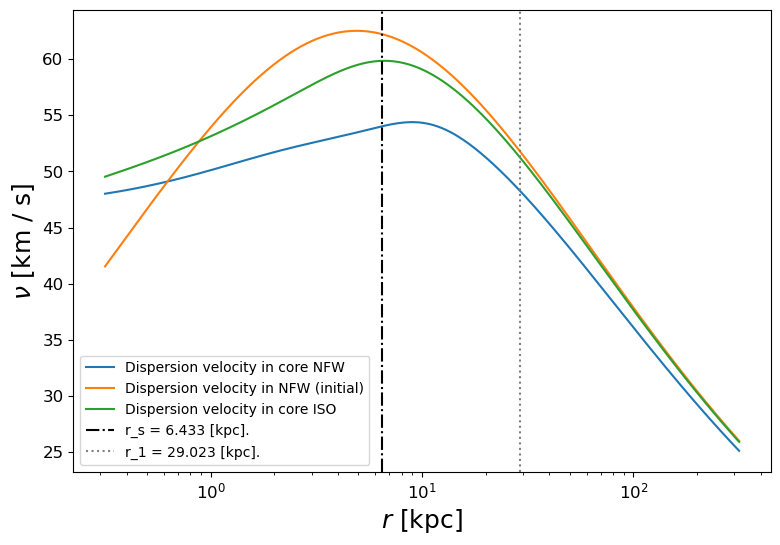

In [18]:
# Plotting
fig, ax = plt.subplots(figsize=(9.0, 6.0))
ax.plot(r, velDisp_cNFW, label="Dispersion velocity in core NFW")
ax.plot(r, velDisp_NFW, label="Dispersion velocity in NFW (initial)")
ax.plot(r, velDisp_cISO, label="Dispersion velocity in core ISO")


# lines
plt.axvline(x=r_s, color='black', linestyle='dashdot',
            label=f'r_s = {"{:.3f}".format(r_s)} [kpc].')
plt.axvline(x=r1marge, color='grey', linestyle='dotted',
            label=f'r_1 = {"{:.3f}".format(r1marge)} [kpc].')
# log scale
ax.set_xscale('log')
# ax.set_yscale('log')
# describe NFW profile
# plt.ylim(10**0, 5*10**2)
plt.ylabel(r"$\nu$ [km / s]", fontsize=18)
plt.xlabel(r"$r$ [kpc]", fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.legend()
plt.show()